---
tags: [integration, optimization, variational]
---

# Qiskitサポート

このページでは、具体的な最適化問題を通して、Qamomileの[Qiskit](https://quantum-computing.ibm.com/docs/)量子SDK連携を紹介します。
QiskitはQamomileの標準の量子SDK連携です。`qamomile`をインストールすれば、`QiskitTranspiler`と`QiskitExecutor`をすぐに使えます。
このチュートリアルでは、小さなMaxCutインスタンスに対するQAOA最適化を例に、Qamomileの量子カーネルをQiskit回路へトランスパイルし、Qiskitシミュレータ上でサンプリングと期待値評価を行います。
さらに、Qiskitの高度な回路機能も紹介します。

In [1]:
# 最新のQamomileをpipからインストールします。
# Qiskitとqiskit-aerはコア依存なので、追加の依存グループは不要です。
# !pip install qamomile

In [2]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.optimization.binary_model import BinaryModel
from qamomile.qiskit import QiskitTranspiler

## MaxCut問題

Qiskit連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを使います。
$\sum_{(i,j) \in E}(1 - s_i s_j)/2$の最大化は、定数項を除けば、反強磁性Isingハミルトニアン$H_C = \sum_{(i,j) \in E} s_i s_j$の最小化に対応します。
重みなしのMaxCutでは、すべての$J_{ij} = 1$、$h_i = 0$なので、これらの係数をそのまま`BinaryModel.from_ising`に渡します。

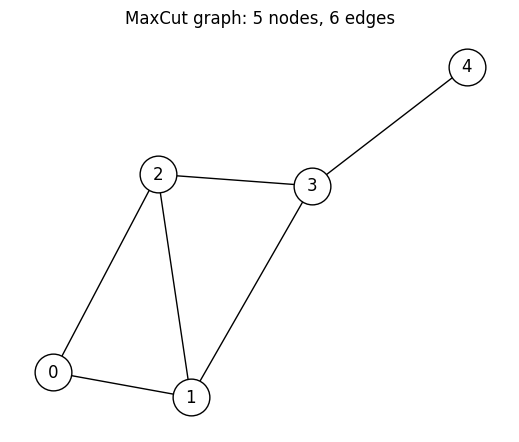

In [3]:
# MaxCutグラフを作り、Ising形式のBinaryModelへ変換します。
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# 問題の構造はグラフから一意に決まります。重みなしMaxCutでは、quad項は辺と
# 1対1に対応し、linear項は存在しません。
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `@qkernel`によるQAOAアンザッツの構築

MaxCutを解くためのQAOA回路を`@qkernel`として記述します。
レシピは[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じです。
計算基底の一様な重ね合わせ状態を準備した後、コスト層とミキサー層を$p$回交互に適用し、最後に計算基底で測定します。
期待値計算用の量子カーネルは後の`run()`セクションで定義します。こうしておくと、下の回路図では状態準備用のラッパーではなく、サンプリング用アンザッツそのものを確認できます。

:::{tip}
Qamomileの回転ゲートは$e^{-i\theta/2}$という規約に従います。
そのため、$1/2$係数の扱いはコスト層とミキサー層で少し異なります。
ミキサー層では`rx`に$2\beta$を渡すので、$1/2$が打ち消され、教科書通りの$e^{-i\beta X}$になります。
一方、コスト層では`rzz`に$J_{ij} \cdot \gamma$を渡すため、$1/2$は残ります。
この係数の違いは変分パラメータ$\gamma$に吸収しています。つまり、ここで使う$\gamma$は教科書のQAOAの$\gamma$の2倍に相当します。
:::

In [4]:
# グラフの全ノードに対応する一様重ね合わせを準備します。
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q

@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q

@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q

@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)`でQamomileの回路図を描画できます。
問題の構造を決める引数(`p`、`quad`、`linear`、`n`)に値を渡し、層の数とグラフの構造を回路図に反映させます。
一方、`gammas` / `betas`には値を渡さず、後で決めるパラメータとして残します。

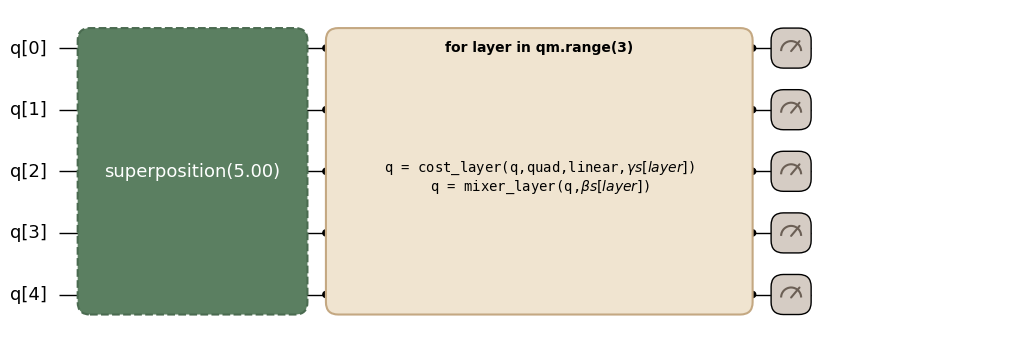

In [5]:
p = 3  # QAOAの層数
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## Qiskitへのトランスパイル

Qamomileの量子カーネルで定義した回路は、`QiskitTranspiler`でQiskitの`QuantumCircuit`へトランスパイルできます。
`QiskitTranspiler`は、他の量子SDKと同じように`transpile()`で使えます。
問題の構造を決める引数は`bindings`で固定し、`gammas` / `betas`はランタイムパラメータとして残します。
チュートリアルの出力を再現できるように、固定シードと`max_parallel_threads=1`を設定した`AerSimulator`を使います。

In [6]:
SEED = 42

def make_seeded_backend() -> AerSimulator:
    return AerSimulator(seed_simulator=SEED, max_parallel_threads=1)

transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()`で内部のQiskit`QuantumCircuit`を取り出せます。
$2p$個のQAOA角度(`gammas[0..p-1]`、`betas[0..p-1]`)は、実行時までQiskitの`Parameter`オブジェクトとして残ります。
ここでは、トランスパイルされた`QuantumCircuit`をQiskitのテキストdrawerで確認します。

In [7]:
# 出力された回路を確認し、パラメータが未バインドのまま残っていることを確認します。
qiskit_circuit = executable.get_first_circuit()
assert qiskit_circuit is not None

# QAOAでは、グラフの各ノードに1つの量子ビットと1つの最終古典ビットを使います。
# ランタイムパラメータは、各層にgammaとbetaが1つずつです。
assert qiskit_circuit.num_qubits == num_nodes
assert qiskit_circuit.num_clbits == num_nodes
assert qiskit_circuit.num_parameters == 2 * p
assert set(executable.parameter_names) == {
    *(f"gammas[{i}]" for i in range(p)),
    *(f"betas[{i}]" for i in range(p)),
}
print(type(qiskit_circuit).__name__)
print("num_qubits    :", qiskit_circuit.num_qubits)
print("num_clbits    :", qiskit_circuit.num_clbits)
print("num_parameters:", qiskit_circuit.num_parameters)
print("parameters    :", sorted(str(param) for param in qiskit_circuit.parameters))

print(qiskit_circuit.draw(output="text", fold=120))

QuantumCircuit
num_qubits    : 5
num_clbits    : 5
num_parameters: 6
parameters    : ['betas[0]', 'betas[1]', 'betas[2]', 'gammas[0]', 'gammas[1]', 'gammas[2]']
     ┌───┐                                ┌────────────────┐                                                    »
q_0: ┤ H ├─■───────────────■──────────────┤ Rx(2*betas[0]) ├────────────────────────────────────■───────────────»
     ├───┤ │ZZ(gammas[0])  │              └────────────────┘                ┌────────────────┐  │ZZ(gammas[1])  »
q_1: ┤ H ├─■───────────────┼────────────────■────────────────■──────────────┤ Rx(2*betas[0]) ├──■───────────────»
     ├───┤                 │ZZ(gammas[0])   │ZZ(gammas[0])   │              └────────────────┘┌────────────────┐»
q_2: ┤ H ├─────────────────■────────────────■────────────────┼────────────────■───────────────┤ Rx(2*betas[0]) ├»
     ├───┤                                                   │ZZ(gammas[0])   │ZZ(gammas[0])  └────────────────┘»
q_3: ┤ H ├───────────────────────────────

各ランタイムパラメータは、実行時まで未バインドのまま残ります。
`gammas` / `betas`のバインドは、`ExecutableProgram.sample(...)`や`ExecutableProgram.run(...)`からQiskitの`assign_parameters`を通して行われるため、Qiskit回路を一度生成すれば、多くのパラメータベクトルで再利用できます。
Ising係数、量子ビット数、層数といった問題構造はトランスパイル時に固定され、ランタイム入力として残るのは変分角度だけです。

## `QiskitExecutor`によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)`は`SampleJob`を返します。
`.result()`で得られる`SampleResult`は、`BinaryModel.decode_from_sampleresult`でスピン変数$(+1 / -1)$の`BinarySampleSet`へデコードできます。
これにより、追加の変換をせずにカット辺を数えられます。
qiskit-aerがインストールされている環境では、`QiskitExecutor()`はデフォルトで`AerSimulator`を使います。ここでは上で作ったシード付きシミュレータを使います。

In [8]:
rng = np.random.default_rng(SEED)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

# パラメータ化されたexecutableをサンプリングし、ビット列をIsingエネルギーへデコードします。
executor = transpiler.executor(backend=make_seeded_backend())
sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")
assert sample_result.shots == sample_shots

Mean energy at random init: -0.6840


## QAOAパラメータの最適化

同じ`executable`を異なる`(gammas, betas)`で繰り返し呼び出すのが、QAOAの最適化ループの基本形です。
`transpiler.transpile()`を1回呼び、その後は`executable.sample()`を何度も呼び出します。
この例では、サンプリングとデコードの処理を`cost_fn()`として定義し、SciPyの`minimize`関数で最適化します。
古典最適化関数は`(gammas, betas)`を更新しながら、サンプリングされたIsingエネルギーの平均を下げていきます。
各反復では、同じ`executable`と`QiskitExecutor`を再利用します。

In [9]:
# 1つのexecutableを古典目的関数の中で再利用します。
cost_history: list[float] = []

def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy

# COBYLAでサンプリング平均エネルギーを最適化します。
res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")
assert cost_history

Optimized mean energy: -2.8810
Optimal gammas       : [0.8678, -0.4364, 1.562]
Optimal betas        : [0.4086, -0.8709, 2.9557]


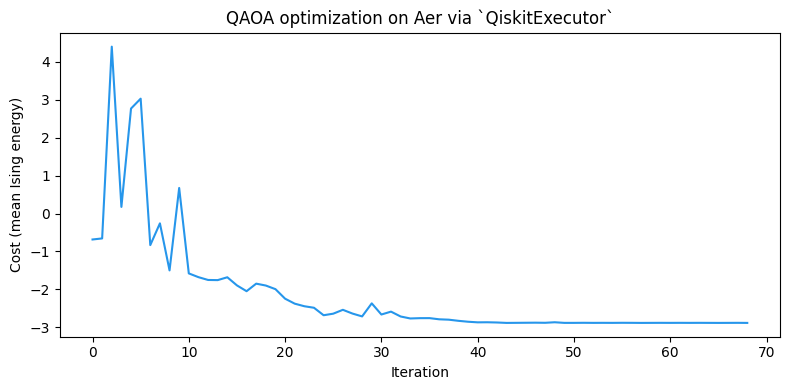

In [10]:
# 最適化の過程における目的関数の変化をプロットします。
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Aer via `QiskitExecutor`")
plt.tight_layout()
plt.show()

上の`AerSimulator`は固定の`seed_simulator`で構築しているため、同じ回路列に対して再現可能なサンプリング列が得られます。
この5ノードグラフでは、$H_C$の基底状態エネルギー付近まで収束するはずです。
ここで得た最適パラメータ(`opt_gammas`、`opt_betas`)を、以降の例でも使います。

## `run()`による期待値計算

Qamomileでは、量子回路の出力に対する期待値を量子カーネル内の`qmc.expval(...)`で記述します。
これをQiskitへトランスパイルすると、`ExecutableProgram.run(executor, bindings=...)`で呼び出せる実行可能オブジェクトになります。
`run()`はQamomileのパラメータ情報を使ってランタイムパラメータをバインドし、そのうえでQiskitのestimatorを呼び出します。

まず$H_C = \sum_{(i,j) \in E} Z_i Z_j$をQamomileの`Hamiltonian`として組み立てます。
その後、期待値計算用の量子カーネルをトランスパイルし、最適化済みQAOAパラメータで評価します。

In [11]:
# MaxCutのIsingコストに対応するQamomile Hamiltonianを組み立てます。
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

# 期待値計算用の量子カーネルを定義します。
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


# 期待値計算用の量子カーネルをトランスパイルし、`run()`で評価します。
expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_via_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"Executable.run() expectation: {energy_via_run:+.10f}")
print(f"sample mean energy          : {res.fun:+.4f}")
assert np.isfinite(energy_via_run)

Executable.run() expectation: -2.8538574303
sample mean energy          : -2.8810


QamomileのAPIだけで扱う場合は、`ExecutableProgram.run(...)`を使うのがおすすめです。
Qiskit回路を自分で扱いたい場合には`executor.estimate(...)`も使えますが、その場合はQiskitのパラメータ順や回路のバインド状態をユーザー側で管理する必要があります。
`QiskitExecutor`は、利用可能な場合にはデフォルトでQiskitの`StatevectorEstimator`を生成するため、現在のQiskit環境ではV2 primitiveインターフェースを使います。
カスタムestimatorや古いQiskit / AerのestimatorがV2形式の`run([(circuit, observable, params)])`呼び出しを受け付けない場合、QamomileはV1形式の`run(circuits, observables, parameter_values)`へフォールバックします。

## Qiskitの高度な機能

Qamomileでは、Qiskitを標準の量子SDK連携として使えます。
そのため、Qiskitが持つ高度な回路機能を活用するための入口も用意しています。

このセクションでは、生成した回路をQiskitの実行対象へ渡すときに便利な機能を3つ示します。

- 動的回路のためのネイティブ古典制御フロー(`for_loop`、`if_else`、`while_loop`)
- パラメトリックな時間発展`qmc.pauli_evolve(...)`をQiskitネイティブな`PauliEvolutionGate`として直接出力
- QamomileのコンポジットQFT操作向けのネイティブ`QFTGate` / 逆`QFTGate`

### 古典制御フローとランタイム古典式

Qiskit連携は、Qamomileの古典制御フローやランタイム古典式を、Qiskitの動的回路命令や古典式に直接変換できます。
`qmc.range(...)`ループは、Qiskitの`for_loop`になります。
測定結果に基づく`if` / `else`と`while`は、Qiskitの動的回路命令になります。
`a & b`のような条件式は、`qiskit.circuit.classical.expr`を通してQiskitの古典式に直接変換できます。

In [12]:
# ネイティブ制御フローの出力を確認する小さな量子カーネルを3つ定義します。

# qmc.rangeによるforループは、Qiskitの`for_loop`になります。
@qmc.qkernel
def native_for_demo(reps: qmc.UInt) -> qmc.Bit:
    q = qmc.qubit("q")
    for _ in qmc.range(reps):
        q = qmc.h(q)
    return qmc.measure(q)

# 測定結果に基づくif分岐は、Qiskitの`if_else`になります。
@qmc.qkernel
def runtime_branch_demo() -> qmc.Bit:
    a = qmc.qubit("a")
    b = qmc.qubit("b")
    target = qmc.qubit("target")

    a = qmc.x(a)
    b = qmc.x(b)
    ma = qmc.measure(a)
    mb = qmc.measure(b)

    if ma & mb:
        target = qmc.x(target)
    else:
        target = qmc.h(target)

    return qmc.measure(target)

# 測定結果に基づくwhileループは、Qiskitの`while_loop`になります。
@qmc.qkernel
def repeat_until_zero_once() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    while bit:
        q1 = qmc.qubit("q1")
        bit = qmc.measure(q1)
    return bit

# 各demoをトランスパイルし、出力されたQiskitの操作名を確認します。
for_circuit = transpiler.to_circuit(native_for_demo, bindings={"reps": 3})
branch_circuit = transpiler.to_circuit(runtime_branch_demo)
while_circuit = transpiler.to_circuit(repeat_until_zero_once)

for_ops = [inst.operation.name for inst in for_circuit.data]
branch_ops = [inst.operation.name for inst in branch_circuit.data]
while_ops = [inst.operation.name for inst in while_circuit.data]

print("native_for_demo ops       :", for_ops)
print("runtime_branch_demo ops   :", branch_ops)
print("repeat_until_zero_once ops:", while_ops)
assert "for_loop" in for_ops
assert "if_else" in branch_ops
assert "while_loop" in while_ops

if_op = next(inst.operation for inst in branch_circuit.data if inst.operation.name == "if_else")
print("if_else condition:", if_op.condition)

native_for_demo ops       : ['for_loop', 'measure']
runtime_branch_demo ops   : ['x', 'x', 'measure', 'measure', 'if_else', 'measure']
repeat_until_zero_once ops: ['x', 'measure', 'while_loop']
if_else condition: Binary(Binary.<Op.LOGIC_AND: 4>, Var(<Clbit register=(3, "c"), index=0>, Bool()), Var(<Clbit register=(3, "c"), index=1>, Bool()), Bool())


Qiskitの古典式システムは現在、Qamomileが扱うことのできる多くの論理演算、比較演算、算術演算に対応しています。
ただし、`FLOORDIV`と`POW`には対応するQiskitの古典式がないため、どちらかが回路実行時に評価する式として残ると、Qiskit回路を構築する前のtarget legality検証で`TargetCapabilityError`が発生します。
これらが必要な場合は、トランスパイル前に具体値として決まる形にしてください。

### ネイティブ`PauliEvolutionGate`

`qmc.pauli_evolve(q, H, gamma)`は、Qamomileの中間表現では$e^{-i\gamma H}$を表します。
Qiskit連携は、`use_native_pauli_evolution=True`(デフォルト)の場合、この操作を`PauliEvolutionGate`として出力します。
未バインドの`gamma`はQiskitの`Parameter`になるため、同じ回路を変分パラメータを変えながら評価する用途に再利用できます。

In [13]:
# Pauli発展の量子カーネルを出力し、Qiskitでネイティブ表現が保たれることを確認します。
@qmc.qkernel
def pauli_evolve_demo(
    n: qmc.UInt,
    H: qmc.Observable,
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Bit]:
    # Hamiltonianによる時間発展を適用する前に、単純な入力状態を準備します。
    q = qmc.qubit_array(n, "q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    q = qmc.pauli_evolve(q, H, gamma)
    return qmc.measure(q)

# 出力された操作を確認しやすいよう、小さなHamiltonianを使います。
evolution_hamiltonian = qm_o.Z(0) * qm_o.Z(1) + 0.5 * qm_o.X(0)
evolution_executable = transpiler.transpile(
    pauli_evolve_demo,
    bindings={"n": evolution_hamiltonian.num_qubits, "H": evolution_hamiltonian},
    parameters=["gamma"],
)
evolution_circuit = evolution_executable.get_first_circuit()
assert evolution_circuit is not None
evolution_ops = [inst.operation.name for inst in evolution_circuit.data]
print(evolution_ops)
assert "PauliEvolution" in evolution_ops
assert {str(param) for param in evolution_circuit.parameters} == {"gamma"}

['h', 'h', 'PauliEvolution', 'measure', 'measure']


量子SDKに依存しないゲート分解を確認したい場合は、`QiskitTranspiler(use_native_pauli_evolution=False)`を渡します。
このフラグが制御するのはPauli発展だけです。ネイティブQFT/IQFT出力は`use_native_composite`で独立に制御します。

### ネイティブ`QFTGate`

Qamomileには、QFTや逆QFTを`qmc.qft(...)` / `qmc.iqft(...)`で表す高水準の操作があります。
Qiskit連携では、これらの量子カーネルを量子ゲートへ分解せず、Qiskitネイティブな`QFTGate`として直接出力できます。
量子ゲートに分解された回路が必要な場合は、`use_native_composite=False`を指定すると、H/controlled-phase/SWAPに展開されます。

In [14]:
# QiskitのネイティブQFTゲートと、ゲート分解された回路を比較します。
@qmc.qkernel
def qft_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q = qmc.qft(q)
    return qmc.measure(q)


qft_native = QiskitTranspiler(use_native_composite=True).to_circuit(
    qft_demo,
    bindings={"n": 3},
)
qft_decomposed = QiskitTranspiler(use_native_composite=False).to_circuit(
    qft_demo,
    bindings={"n": 3},
)
native_ops = [inst.operation.name for inst in qft_native.data]
decomposed_ops = [inst.operation.name for inst in qft_decomposed.data]
print("native QFT ops    :", native_ops)
print("decomposed QFT ops:", decomposed_ops)
assert any("qft" in name.lower() for name in native_ops)
assert "cp" in decomposed_ops
assert len(qft_native.data) < len(qft_decomposed.data)

native QFT ops    : ['qft', 'measure', 'measure', 'measure']
decomposed QFT ops: ['h', 'cp', 'cp', 'h', 'cp', 'h', 'swap', 'measure', 'measure', 'measure']


## 他のQiskit実行対象の利用

`QiskitExecutor`では、トランスパイル済み回路と、それを実行するQiskitの実行対象を分けて扱います。
そのため、`transpiler.executor(backend=...)`でQiskitの実行対象を差し替えるだけで、同じ回路をさまざまなQiskit実行対象で実行できます。
例えば、ノイズなしのローカルシミュレータやAerノイズモデルに加えて、IBM Quantumが提供する実機も利用できます。

ここでは、脱分極ノイズを持つAerノイズモデルを作り、`AerSimulator`へ渡す例を示します。
同じ最適化済みパラメータで、ノイズなしとノイズありのサンプル平均エネルギーを比較します。

In [15]:
# 1量子ビットゲートと2量子ビットゲートの脱分極ノイズを持つAerノイズモデルを作ります。
noise_model = NoiseModel()
one_qubit_error = depolarizing_error(0.01, 1)
two_qubit_error = depolarizing_error(0.02, 2)
noise_model.add_all_qubit_quantum_error(one_qubit_error, ["h", "rx", "rz"])
noise_model.add_all_qubit_quantum_error(two_qubit_error, ["rzz"])

noisy_backend = AerSimulator(
    noise_model=noise_model,
    seed_simulator=SEED,
    max_parallel_threads=1,
)
noisy_executor = transpiler.executor(backend=noisy_backend)

# 同じexecutableを、ノイズなしとノイズありの実行対象で実行します。
clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

# 両方のサンプル集合をデコードし、平均Isingエネルギーを比較します。
clean_energy = spin_model.decode_from_sampleresult(clean_result).energy_mean()
noisy_energy = spin_model.decode_from_sampleresult(noisy_result).energy_mean()
print(f"noiseless Aer mean energy: {clean_energy:+.4f}")
print(f"noisy Aer mean energy: {noisy_energy:+.4f}")
assert clean_result.shots == sample_shots
assert noisy_result.shots == sample_shots
assert np.isfinite(clean_energy)
assert np.isfinite(noisy_energy)

noiseless Aer mean energy: -2.8810
noisy Aer mean energy: -2.1370


## まとめ

- `QiskitTranspiler().transpile(kernel, bindings=..., parameters=[...])`は量子カーネルを`ExecutableProgram[QuantumCircuit]`に変換します。Qiskitエコシステム内で扱いたい場合は、`to_circuit(...)`で生のQiskit`QuantumCircuit`を取得できます。
- `QiskitExecutor`は、測定を返す量子カーネル向けの`executable.sample()`と、期待値向けの`executable.run()` / `executor.estimate(...)`の両方をサポートします。デフォルトでは`AerSimulator`を使い、`transpiler.executor(backend=...)`から任意のQiskit実行対象オブジェクトを受け取れます。
- Qiskit連携は、Qiskitが高い抽象度の回路命令を持つ箇所では、回路途中の測定、動的`for_loop` / `if_else` / `while_loop`、ランタイム古典式、`PauliEvolutionGate`、`QFTGate`をネイティブに出力します。
- Aerノイズモデル、providerが提供する実行対象、qBraidでラップしたQiskitデバイスを、qkernelを再トランスパイルせずに使えます。`qamomile.optimization`のヘルパーも、同じQiskit回路を受け渡す仕組みを使っています。

### 関連ページ

- [CUDA-Qサポート](cudaq_support.ipynb)では、同じMaxCut QAOAの流れをCUDA-Q連携で扱い、CUDA-Q targetや`observe`も確認します。
- [QURI Partsサポート](quri_parts_support.ipynb)では、同じ流れをQURI Partsで扱い、Qulacs samplerやQURI Parts estimatorの経路も確認します。